In [1]:
import os
import json
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr

folder_path = r"D:\OneDrive\Trading\Market Making\data\runs\run_20260905_123159_live"

fills = pd.read_parquet(os.path.join(folder_path, "fills.parquet"))
fills

,ts,exchange_latency,time_to_fill,symbol,side,price,price_tick,qty,cum_qty,is_maker,...,ask_distance_spread,snap_mid,signed_markout_100ms,signed_adverse_100ms,signed_markout_500ms,signed_adverse_500ms,signed_markout_1000ms,signed_adverse_1000ms,signed_markout_5000ms,signed_adverse_5000ms
0,1788611573499,49733,49694,PEPEUSDT,SELL,0.000004,353,312057.0,312057.0,True,...,1.000000e-08,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09
1,1788611573624,40,0,PEPEUSDT,SELL,0.000004,353,312057.0,312057.0,False,...,0.000000e+00,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09
2,1788611860400,827,787,PEPEUSDT,BUY,0.000004,355,821667.0,821667.0,True,...,1.000000e-08,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,5.000000e-09,-5.000000e-09
3,1788611860487,40,0,PEPEUSDT,BUY,0.000004,355,821667.0,821667.0,False,...,2.000000e-08,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,5.000000e-09,-5.000000e-09
4,1788611862291,722,685,PEPEUSDT,SELL,0.000004,355,842248.0,842248.0,True,...,1.000000e-08,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09
5,1788611862385,-52,0,PEPEUSDT,SELL,0.000004,355,842248.0,842248.0,False,...,0.000000e+00,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09
6,1788611873767,10203,10162,PEPEUSDT,BUY,0.000004,355,826512.0,826512.0,True,...,1.000000e-08,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09
7,1788611873897,41,0,PEPEUSDT,BUY,0.000004,355,826512.0,826512.0,False,...,2.000000e-08,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09
8,1788611891214,16340,16302,PEPEUSDT,SELL,0.000004,355,841942.0,841942.0,True,...,1.000000e-08,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09
9,1788611891314,-70,0,PEPEUSDT,SELL,0.000004,355,841942.0,841942.0,False,...,0.000000e+00,0.000004,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09,-5.000000e-09,5.000000e-09


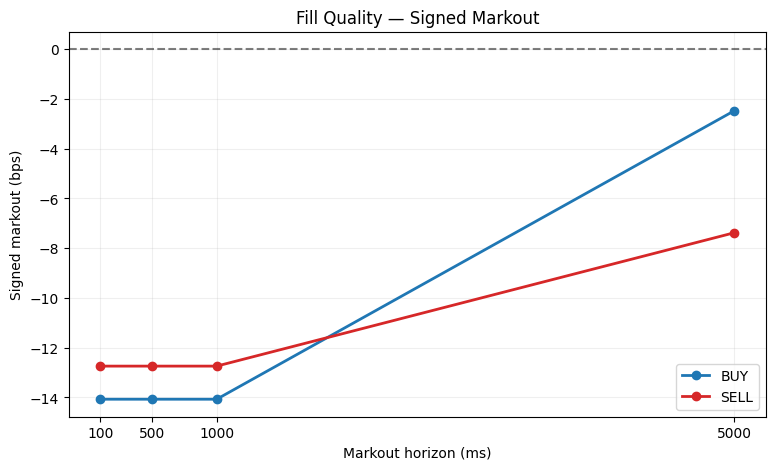

In [3]:
import matplotlib.pyplot as plt
import numpy as np
horizons = [100, 500, 1000, 5000]
for h in horizons:
    fills[f"markout_{h}ms_bps"] = (
        fills[f"signed_markout_{h}ms"]
        / fills["snap_mid"]
        * 10_000
    )


cols_bps = [f"markout_{h}ms_bps" for h in horizons]

fig, ax = plt.subplots(figsize=(9, 5))

for side, color in [("BUY", "tab:blue"), ("SELL", "tab:red")]:
    subset = fills[fills["side"] == side]

    means = subset[cols_bps].mean()

    ax.plot(
        horizons,
        means.values,
        marker="o",
        linewidth=2,
        label=side,
        color=color,
    )

ax.axhline(0, color="black", linestyle="--", alpha=0.5)

ax.set_xlabel("Markout horizon (ms)")
ax.set_ylabel("Signed markout (bps)")
ax.set_title("Fill Quality — Signed Markout")
ax.set_xticks(horizons)
ax.legend()
ax.grid(alpha=0.2)

plt.show()

In [7]:
markout_df = pd.DataFrame({
    "horizon_ms": horizons,
    "markout_bps": [
        fills[f"markout_{h}ms_bps"].mean()
        for h in horizons
    ]
})

markout_df

,horizon_ms,markout_bps
0,100,-13.333912
1,500,-13.333912
2,1000,-13.333912
3,5000,-5.182828


In [6]:
markout_df = pd.DataFrame({
    "horizon_ms": horizons,
    "buy_markout_bps": [
        fills.loc[fills["side"] == "BUY", f"markout_{h}ms_bps"].mean()
        for h in horizons
    ],
    "sell_markout_bps": [
        fills.loc[fills["side"] == "SELL", f"markout_{h}ms_bps"].mean()
        for h in horizons
    ],
})

markout_df

,horizon_ms,buy_markout_bps,sell_markout_bps
0,100,-14.069405,-12.738513
1,500,-14.069405,-12.738513
2,1000,-14.069405,-12.738513
3,5000,-2.472710,-7.376733


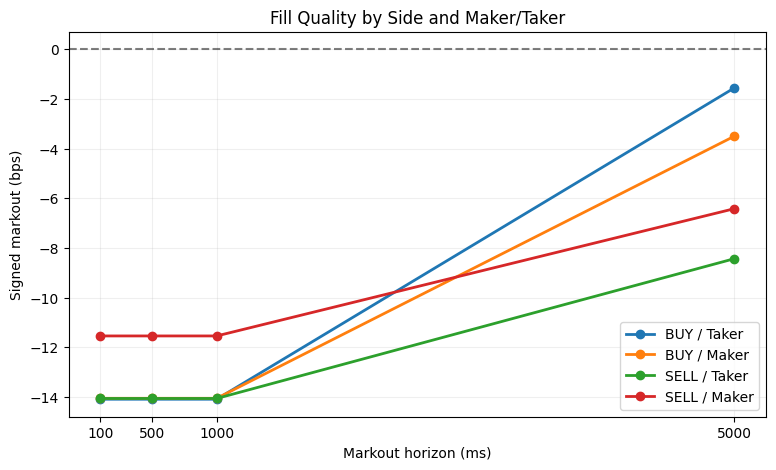

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

for (side, is_maker), group in fills.groupby(["side", "is_maker"]):

    means = group[cols_bps].mean()

    label = f"{side} / {'Maker' if is_maker else 'Taker'}"

    ax.plot(
        horizons,
        means.values,
        marker="o",
        linewidth=2,
        label=label,
    )

ax.axhline(0, color="black", linestyle="--", alpha=0.5)

ax.set_xlabel("Markout horizon (ms)")
ax.set_ylabel("Signed markout (bps)")
ax.set_title("Fill Quality by Side and Maker/Taker")
ax.set_xticks(horizons)
ax.legend()
ax.grid(alpha=0.2)

plt.show()

In [7]:
import os
import json
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr

folder_path = r"D:\OneDrive\Trading\Market Making\data/runs/run_20260911_141429_live1"

snapshots = pd.read_parquet(os.path.join(folder_path, "snapshots.parquet"))
fills = pd.read_parquet(os.path.join(folder_path, "fills.parquet"))
fills

,fill_ts,exchange_latency,time_to_fill,symbol,side,price,price_tick,qty,cum_qty,is_maker,...,signed_adverse_1000ms,signed_markout_5000ms,signed_adverse_5000ms,snapshot_ts,micro_signal,quote_churn,snapshot_age_ms,regime_0,regime_1,regime_2
0,1789136087598,16429,16387,PEPEUSDT,BUY,0.000003,349,314736.0,314736.0,True,...,5.000000e-09,-5.000000e-09,5.000000e-09,1789136087544,-0.000736,0.0,54,1.0,0.0,0.0
1,1789136088518,-65,0,PEPEUSDT,BUY,0.000003,349,314736.0,314736.0,False,...,5.000000e-09,-5.000000e-09,5.000000e-09,1789136088444,0.000315,0.0,74,1.0,0.0,0.0
2,1789136164142,761,721,PEPEUSDT,SELL,0.000003,348,839330.0,839330.0,True,...,-5.000000e-09,5.000000e-09,-5.000000e-09,1789136164044,0.000817,0.0,98,1.0,0.0,0.0
3,1789136197117,32923,32883,PEPEUSDT,SELL,0.000003,349,839330.0,839330.0,True,...,5.000000e-09,5.000000e-09,-5.000000e-09,1789136196944,0.000985,0.0,173,0.0,1.0,0.0
4,1789136201394,3212,3171,PEPEUSDT,BUY,0.000003,349,854424.0,854424.0,True,...,5.000000e-09,5.000000e-09,-5.000000e-09,1789136201244,-0.001137,0.0,150,1.0,0.0,0.0
5,1789136201485,42,0,PEPEUSDT,BUY,0.000003,349,854424.0,854424.0,False,...,5.000000e-09,5.000000e-09,-5.000000e-09,1789136201444,0.000829,0.0,41,1.0,0.0,0.0
6,1789136381025,26442,26401,PEPEUSDT,SELL,0.000003,350,838861.0,838861.0,True,...,5.000000e-09,-5.000000e-09,5.000000e-09,1789136380844,0.001014,0.0,181,1.0,0.0,0.0
7,1789136381123,-175,0,PEPEUSDT,SELL,0.000003,350,838861.0,838861.0,False,...,5.000000e-09,-5.000000e-09,5.000000e-09,1789136381044,-0.000765,0.0,79,1.0,0.0,0.0
8,1789136383181,998,956,PEPEUSDT,BUY,0.000003,350,851744.0,851744.0,True,...,-5.000000e-09,5.000000e-09,-5.000000e-09,1789136383144,-0.000872,0.0,37,1.0,0.0,0.0
9,1789136383181,-63,0,PEPEUSDT,BUY,0.000003,350,851744.0,851744.0,False,...,-5.000000e-09,5.000000e-09,-5.000000e-09,1789136383144,-0.000872,0.0,37,1.0,0.0,0.0


In [8]:
fills["snapshot_age_ms"].describe()

count     15.000000
mean      89.266667
std       47.222069
min       37.000000
25%       47.500000
50%       89.000000
75%       97.500000
max      181.000000
Name: snapshot_age_ms, dtype: float64

In [11]:
fills["signed_micro_signal"] = (fills["micro_signal"] * fills["fill_sign"])
fills["signal_bucket"] = pd.qcut(
    fills["signed_micro_signal"],
    10,
    labels=False,
    duplicates="drop"
)

result = (
    fills
    .groupby("signal_bucket")
    .agg(
        fill_count=("signed_micro_signal", "size"),
        signal_mean=("signed_micro_signal", "mean"),
        mo_100ms=("signed_markout_100ms", "mean"),
        mo_500ms=("signed_markout_500ms", "mean"),
        mo_1000ms=("signed_markout_1000ms", "mean"),
        mo_5000ms=("signed_markout_5000ms", "mean"),
    )
)

print(result)

               fill_count  signal_mean      mo_100ms      mo_500ms  \
signal_bucket                                                        
0                       2    -0.001266 -5.000000e-09 -5.000000e-09   
1                       1    -0.001035  5.000000e-09  5.000000e-09   
2                       2    -0.001000 -5.000000e-09 -5.000000e-09   
3                       1    -0.000914 -5.000000e-09 -5.000000e-09   
4                       2    -0.000872 -5.000000e-09 -5.000000e-09   
5                       1    -0.000817 -5.000000e-09  5.000000e-09   
6                       1    -0.000736  5.000000e-09  5.000000e-09   
7                       2     0.000540 -5.000000e-09 -5.000000e-09   
8                       1     0.000829 -5.000000e-09 -5.000000e-09   
9                       2     0.000956 -5.000000e-09 -5.000000e-09   

                  mo_1000ms     mo_5000ms  
signal_bucket                              
0             -5.000000e-09  5.000000e-09  
1              5.000000e-09

In [12]:
import statsmodels.api as sm

x = fills["signed_micro_signal"]
y = fills["signed_markout_5000ms"]

X = sm.add_constant(x)

model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     signed_markout_5000ms   R-squared:                       0.062
Model:                               OLS   Adj. R-squared:                 -0.010
Method:                    Least Squares   F-statistic:                    0.8666
Date:                   Sun, 13 Sep 2026   Prob (F-statistic):              0.369
Time:                           20:15:05   Log-Likelihood:                 266.21
No. Observations:                     15   AIC:                            -528.4
Df Residuals:                         13   BIC:                            -527.0
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
cons

In [ ]:
g = fills.groupby("signal_bucket")

result = g["signed_markout_5000ms"].agg(
    n="count",
    mean="mean",
    std="std"
)

result["se"] = result["std"] / np.sqrt(result["n"])
result["ci95"] = 1.96 * result["se"]
result


,n,mean,std,se,ci95
signal_bucket,,,,,
0,2,5.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00
1,1,-5.000000e-09,NaN,NaN,NaN
2,2,-2.117582e-22,7.071068e-09,5.000000e-09,9.800000e-09
3,1,5.000000e-09,NaN,NaN,NaN
4,2,5.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00
5,1,5.000000e-09,NaN,NaN,NaN
6,1,-5.000000e-09,NaN,NaN,NaN
7,2,-5.000000e-09,2.994714e-22,2.117582e-22,4.150461e-22
8,1,5.000000e-09,NaN,NaN,NaN


In [ ]:
"""
model = predict adverse selection

                ┌──────────────┐
market ───────► │ regime model │ ───► policy params
                └──────┬───────┘
                       │
                       ▼
        ┌──────────────────────────┐
        │ alpha / fair value stack │ ───► center
        └──────────┬───────────────┘
                   │
                   ▼
        ┌──────────────────────────┐
        │ toxicity model           │ ───► risk modifiers
        └──────────┬───────────────┘
                   │
                   ▼
             execution engine

So your best toxicity model is actually:

E[future markout loss | fill now]

That is the true label your XGBoost model should learn.

Not classification. Not heuristic imbalance.
"""

df = fills

horizons = [100, 500, 1000, 5000]

feature_cols = [
    "spread",
    "volatility",
    "order_imbalance",
    "trade_imbalance",
    "microprice_dev",
    "regime_0",
    "regime_1",
    "regime_2",
]

df = df.dropna()

split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

X_train = train[feature_cols].to_numpy(dtype=np.float32)
X_test = test[feature_cols].to_numpy(dtype=np.float32)

In [23]:
def ic(pred, y):
    return np.corrcoef(pred, y)[0, 1]

def rank_ic(pred, y):
    return spearmanr(pred, y).statistic

results = {}
models = {}

for h in horizons:

    y_train = train[f"signed_markout_{h}ms"]
    y_test = test[f"signed_markout_{h}ms"]

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    tox_std = np.std(train_pred)
    tox_mean_abs = np.mean(np.abs(train_pred))

    pred = model.predict(X_test)
    true = y_test.values

    # -------------------------
    # signal quality
    # -------------------------
    residual_ic = ic(pred, true)
    residual_rank_ic = rank_ic(pred, true)

    # -------------------------
    # direction accuracy
    # -------------------------
    hit_rate = (np.sign(pred) == np.sign(true)).mean()

    # -------------------------
    # true economic interpretation
    # -------------------------
    pnl_proxy = np.mean(pred * true)
    pnl_std = np.std(pred * true) + 1e-9
    sharpe_proxy = pnl_proxy / pnl_std

    # -------------------------
    # toxicity
    # -------------------------
    #   pred > 0  = predicted favorable markout
    #   pred < 0  = predicted adverse/toxic markout
    #
    # Toxicity:
    #   tox > 0   = more toxic
    #   tox < 0   = more favorable

    # Toxicity distribution
    tox = -pred
    tox_p50 = np.percentile(tox, 50)
    tox_p75 = np.percentile(tox, 75)
    tox_p90 = np.percentile(tox, 90)
    tox_p95 = np.percentile(tox, 95)
    tox_p99 = np.percentile(tox, 99)

    models[h] = {
        "model": model,
        "tox_std": tox_std,
        "tox_mean_abs": tox_mean_abs
    }
    results[h] = {
        "Residual_IC": residual_ic,
        "Residual_Rank_IC": residual_rank_ic,
        "HitRate": hit_rate,
        "PnLProxy": pnl_proxy,
        "SharpeProxy": sharpe_proxy,

        "Tox_P50": tox_p50,
        "Tox_P75": tox_p75,
        "Tox_P90": tox_p90,
        "Tox_P95": tox_p95,
        "Tox_P99": tox_p99,
    }

pd.set_option('display.float_format', '{:.18f}'.format)
results_df = pd.DataFrame(results)
results_df

c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\admin\AppData\Local\Temp\ipykernel_27260\2400133669.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(pred, y).statistic


,100,500,1000,5000
Residual_IC,NaN,NaN,NaN,NaN
Residual_Rank_IC,NaN,NaN,NaN,NaN
HitRate,0.875000000000000000,0.875000000000000000,0.875000000000000000,0.625000000000000000
PnLProxy,0.000000000000000019,0.000000000000000019,0.000000000000000019,0.000000000000000003
SharpeProxy,0.000000018749999576,0.000000018749999576,0.000000018749999576,0.000000002653899573
Tox_P50,0.000000004999999970,0.000000004999999970,0.000000004999999970,0.000000002123119680
Tox_P75,0.000000004999999970,0.000000004999999970,0.000000004999999970,0.000000002123119680
Tox_P90,0.000000004999999970,0.000000004999999970,0.000000004999999970,0.000000002123119680
Tox_P95,0.000000004999999970,0.000000004999999970,0.000000004999999970,0.000000002123119680
Tox_P99,0.000000004999999970,0.000000004999999970,0.000000004999999970,0.000000002123119680


In [11]:
"""
SharpeProxy increasing with horizon

This is actually the key signal:

100ms → weak economic signal
500-1000ms → stronger signal

This tells you:

toxicity is not instantaneous micro-noise, it is short-horizon information flow

That's exactly what informed order flow looks like.

3. The important conceptual insight

You are NOT building:

a price predictor

You ARE building:

a liquidity filter

This model answers:

“Should I provide liquidity here or not?”

"""

"\nSharpeProxy increasing with horizon\n\nThis is actually the key signal:\n\n100ms → weak economic signal\n500-1000ms → stronger signal\n\nThis tells you:\n\ntoxicity is not instantaneous micro-noise, it is short-horizon information flow\n\nThat's exactly what informed order flow looks like.\n\n3. The important conceptual insight\n\nYou are NOT building:\n\na price predictor\n\nYou ARE building:\n\na liquidity filter\n\nThis model answers:\n\n“Should I provide liquidity here or not?”\n\n"

In [ ]:
# artifact = {
#     "model": models[100]["model"],
#     "feature_cols": feature_cols,
#     "target": "markout_100ms",
#     "horizon_ms": 100,
# }

# joblib.dump(artifact, "data/toxicity_model.pkl")

['data/toxicity_model.pkl']

In [ ]:
# artifact = {
#     "name": "toxicity_model",
#     "model_file": "toxicity_model_xgb.json",
#     "feature_cols": feature_cols,
#     "feature_dim": len(feature_cols),
#     "target": "markout_100ms",
#     "horizon_ms": 100
# }

# models[100]["model"].save_model("data/toxicity_model_xgb.json")

# with open("data/toxicity_model.json", "w") as f:
#     json.dump(artifact, f, indent=4)

In [24]:
def export_xgb(model_name, target, horizon_ms):
    model = models[horizon_ms]["model"]
    model.save_model(f"data/{model_name}_xgb.json")

    artifact = {
        "model_name": f"{model_name}",
        "target": target,
        "model_file": f"data/{model_name}_xgb.json",
        "horizon_ms": horizon_ms,
        "feature_cols": feature_cols,
        "feature_dim": len(feature_cols)
    }

    with open(f"data/{model_name}.json", "w") as f:
        json.dump(artifact, f, indent=4)
    
    print(f"['data/{model_name}.json']")
    print(f"['data/{model_name}_xgb.json']")

export_xgb(model_name="toxicity_model_pepe", target="markout_1000ms", horizon_ms=1000)

['data/toxicity_model_pepe.json']
['data/toxicity_model_pepe_xgb.json']
